In [ ]:
# Task 3: Neural Networks

## 3.1 Perceptron Training Rule (8 Points)

**Task:** Train a perceptron with the following parameters:
- Bias $x_0 = 1$
- Learning rate $\eta = 0.5$
- Initial weights: $w_0 = 1$, $w_1 = 1$, $w_2 = 1$

**Training Data:**
| ID | $x_1$ | $x_2$ | $t$ |
|----|-------|-------|-----|
| 1  | 0     | 0     | -1  |
| 2  | 0     | 1     | 1   |
| 3  | 1     | 0     | 1   |
| 4  | 1     | 1     | -1  |

In [ ]:
import numpy as np
# numpy (np): Fundamental package for numerical computing in Python
# - Provides multi-dimensional array objects (ndarray)
# - Fast mathematical operations on arrays
# - Linear algebra, random numbers, etc.

# =====================================================
# 3.1 PERCEPTRON TRAINING RULE
# =====================================================

# Training data: [x0 (Bias), x1, x2, t (Label)]
# x0 is always 1 (Bias term)
training_data = [
    [1, 0, 0, -1],  # ID 1
    [1, 0, 1,  1],  # ID 2  
    [1, 1, 0,  1],  # ID 3
    [1, 1, 1, -1],  # ID 4
]

# =============================================================================
# NUMPY FUNCTIONS EXPLAINED
# =============================================================================

# np.array(object, dtype)
# - Creates an ndarray from a list, tuple, or other array-like object
# - object: Input data (list, tuple, nested lists, etc.)
# - dtype: Desired data type (float64, int32, etc.) - optional
# Example: np.array([1, 2, 3]) creates array([1, 2, 3])
w = np.array([1.0, 1.0, 1.0])  # [w0, w1, w2]

# Learning rate
eta = 0.5

def sign(x):
    """
    Threshold function (Sign/Step function)
    
    Parameters:
    -----------
    x : float
        Input value to be thresholded
        
    Returns:
    --------
    int : 1 if x >= 0, otherwise -1
    
    Purpose:
    --------
    - Used as activation function in perceptron
    - Converts continuous net input to discrete output (-1 or +1)
    """
    return 1 if x >= 0 else -1

def perceptron_output(x, w):
    """
    Calculates the output of the perceptron
    
    Parameters:
    -----------
    x : np.array
        Input vector [x0, x1, x2] where x0=1 (bias)
    w : np.array
        Weight vector [w0, w1, w2]
        
    Returns:
    --------
    tuple : (output, net_input)
        - output: Thresholded output (-1 or +1)
        - net_input: Raw weighted sum before thresholding
    
    Calculation:
    ------------
    net = Σ(wi * xi) = w0*x0 + w1*x1 + w2*x2
    output = sign(net)
    """
    # np.dot(a, b)
    # - Computes dot product of two arrays
    # - For 1-D arrays: sum of element-wise products
    # - np.dot([1,2,3], [4,5,6]) = 1*4 + 2*5 + 3*6 = 32
    net = np.dot(w, x)  # Sum: w0*x0 + w1*x1 + w2*x2
    return sign(net), net

def perceptron_training_step(x, t, w, eta):
    """
    Perceptron Training Rule (Weight Update)
    
    Parameters:
    -----------
    x : np.array
        Input vector [x0, x1, x2]
    t : int
        Target/desired output (-1 or +1)
    w : np.array
        Current weight vector [w0, w1, w2]
    eta : float
        Learning rate (η) - controls step size of weight updates
        - Small η (e.g., 0.1): Slow but stable learning
        - Large η (e.g., 1.0): Fast but potentially unstable
        
    Returns:
    --------
    tuple : (output, net_input, delta_weights, new_weights)
        - output: Current perceptron output
        - net_input: Raw weighted sum
        - delta_weights: Change in weights
        - new_weights: Updated weight vector
    
    Formula:
    --------
    Δwi = η * (t - o) * xi
    w_new = w_old + Δw
    
    Where:
    - t = target output (what we want)
    - o = actual output (what we got)
    - (t - o) = error signal
    """
    o, net = perceptron_output(x, w)
    
    # Scalar multiplication with array:
    # eta * (t - o) * x multiplies each element of x by the scalar
    delta_w = eta * (t - o) * x
    
    # Array addition: element-wise addition
    # w + delta_w adds corresponding elements
    w_new = w + delta_w
    return o, net, delta_w, w_new

print("="*70)
print("PERCEPTRON TRAINING")
print("="*70)
print(f"\nInitial weights: w0={w[0]}, w1={w[1]}, w2={w[2]}")
print(f"Learning rate η = {eta}")
print("\nPerceptron Training Rule: Δwi = η * (t - o) * xi")
print("-"*70)

PERCEPTRON TRAINING

Anfangsgewichte: w0=1.0, w1=1.0, w2=1.0
Lernrate η = 0.5

Perceptron Training Rule: Δwi = η * (t - o) * xi
----------------------------------------------------------------------


In [ ]:
# Training step by step
epoch = 0
max_epochs = 20  # Maximum number of epochs

print("\n" + "="*70)
print("TRAINING STEP BY STEP")
print("="*70)

while epoch < max_epochs:
    epoch += 1
    print(f"\n>>> EPOCH {epoch} <<<")
    print("-"*50)
    
    all_correct = True
    
    for i, data in enumerate(training_data):
        x = np.array(data[:3])  # [x0, x1, x2]
        t = data[3]             # Label
        
        o, net, delta_w, w_new = perceptron_training_step(x, t, w, eta)
        
        print(f"\nExample {i+1}: x = {x}, t = {t}")
        print(f"  Net input: net = w · x = {w[0]}*{x[0]} + {w[1]}*{x[1]} + {w[2]}*{x[2]} = {net:.1f}")
        print(f"  Output: o = sign({net:.1f}) = {o}")
        print(f"  Error: t - o = {t} - {o} = {t - o}")
        
        if t != o:
            all_correct = False
            print(f"  WRONG! Weights will be updated:")
            print(f"      Delta_w = eta * (t - o) * x = {eta} * {t - o} * {x} = {delta_w}")
            print(f"      w_old = {w}")
            print(f"      w_new = w_old + Delta_w = {w_new}")
            w = w_new
        else:
            print(f"  CORRECT! No weight update needed.")
    
    print(f"\n  ==> Weights after epoch {epoch}: w = {w}")
    
    if all_correct:
        print(f"\n*** CONVERGED! All examples correctly classified in epoch {epoch}. ***")
        break

if not all_correct:
    print(f"\n*** DID NOT CONVERGE after {max_epochs} epochs! ***")
    print("   This means: The data is NOT linearly separable!")

print(f"\n" + "="*70)
print(f"FINAL WEIGHTS: w0 = {w[0]}, w1 = {w[1]}, w2 = {w[2]}")
print("="*70)


TRAINING SCHRITT FÜR SCHRITT

>>> EPOCHE 1 <<<
--------------------------------------------------

Beispiel 1: x = [1 0 0], t = -1
  Netto-Input: net = w · x = 1.0*1 + 1.0*0 + 1.0*0 = 1.0
  Output: o = sign(1.0) = 1
  Fehler: t - o = -1 - 1 = -2
  FALSCH! Gewichte werden aktualisiert:
      Delta_w = eta * (t - o) * x = 0.5 * -2 * [1 0 0] = [-1. -0. -0.]
      w_alt = [1. 1. 1.]
      w_neu = w_alt + Delta_w = [0. 1. 1.]

Beispiel 2: x = [1 0 1], t = 1
  Netto-Input: net = w · x = 0.0*1 + 1.0*0 + 1.0*1 = 1.0
  Output: o = sign(1.0) = 1
  Fehler: t - o = 1 - 1 = 0
  RICHTIG! Keine Aenderung der Gewichte.

Beispiel 3: x = [1 1 0], t = 1
  Netto-Input: net = w · x = 0.0*1 + 1.0*1 + 1.0*0 = 1.0
  Output: o = sign(1.0) = 1
  Fehler: t - o = 1 - 1 = 0
  RICHTIG! Keine Aenderung der Gewichte.

Beispiel 4: x = [1 1 1], t = -1
  Netto-Input: net = w · x = 0.0*1 + 1.0*1 + 1.0*1 = 2.0
  Output: o = sign(2.0) = 1
  Fehler: t - o = -1 - 1 = -2
  FALSCH! Gewichte werden aktualisiert:
      Delta_w 

## 3.2 Can a Perceptron Learn This Function? (2 Points)

**Question:** Decide whether the function of the dataset in Table 3 can be completely learned by a perceptron.

**Theoretical Justification:**

3.2 ANALYSE: Ist die Funktion linear trennbar?


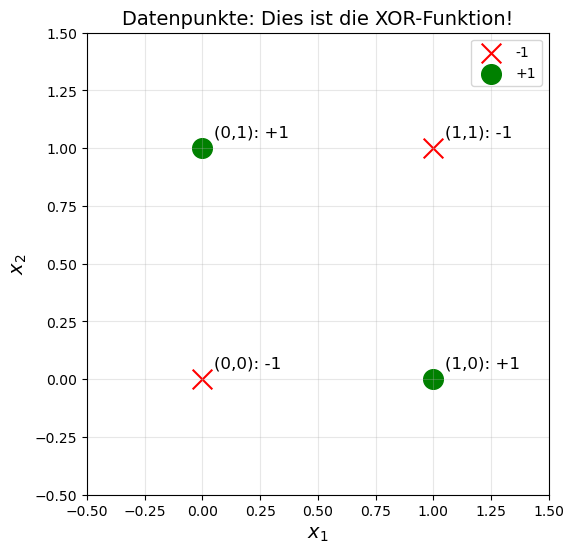


----------------------------------------------------------------------
ERKENNTNIS:
----------------------------------------------------------------------

Die Datenpunkte entsprechen der XOR-Funktion (Exklusiv-Oder):

  | x1 | x2 | XOR |
  |----|----|----|
  | 0  | 0  | -1 |  (beide gleich -> -1)
  | 0  | 1  | +1 |  (unterschiedlich -> +1)
  | 1  | 0  | +1 |  (unterschiedlich -> +1)
  | 1  | 1  | -1 |  (beide gleich -> -1)

ANTWORT: NEIN, ein einzelnes Perzeptron kann diese Funktion NICHT lernen!

BEGRUENDUNG:
- Ein Perzeptron kann nur linear trennbare Funktionen lernen.
- Die XOR-Funktion ist NICHT linear trennbar.
- Es gibt keine gerade Linie, die die gruenen Punkte (+1) von den 
  roten Punkten (-1) trennen kann.
- Die Punkte liegen diagonal zueinander: (0,0) und (1,1) haben Klasse -1,
  waehrend (0,1) und (1,0) Klasse +1 haben.

Um XOR zu lernen, benoetigt man:
- Ein Multilayer Perceptron (MLP) mit mindestens einer versteckten Schicht, ODER
- Kernel-Methoden (z.B. SVM mit nicht-li

In [ ]:
# =====================================================
# 3.2 ANALYSIS: IS THE FUNCTION LINEARLY SEPARABLE?
# =====================================================

import matplotlib.pyplot as plt
# matplotlib.pyplot: Main plotting library for Python
# - Provides MATLAB-like interface for creating visualizations
# - plt is the conventional alias for pyplot

# Data points
data_points = {
    'x1': [0, 0, 1, 1],
    'x2': [0, 1, 0, 1],
    't':  [-1, 1, 1, -1]
}

print("="*70)
print("3.2 ANALYSIS: Is the function linearly separable?")
print("="*70)

# =============================================================================
# MATPLOTLIB FUNCTIONS EXPLAINED
# =============================================================================

# plt.subplots(nrows, ncols, figsize)
# - Creates a figure and a set of subplots
# - figsize: tuple (width, height) in inches - controls the size of the figure
# - Returns: (fig, ax) where fig is the Figure object and ax is the Axes object
fig, ax = plt.subplots(figsize=(8, 6))

for i in range(4):
    x1, x2, t = data_points['x1'][i], data_points['x2'][i], data_points['t'][i]
    if t == 1:
        # ax.scatter(x, y, c, s, marker, label)
        # - x, y: Data positions (coordinates)
        # - c (color): Color of markers ('green', 'red', 'blue', '#FF0000', etc.)
        # - s (size): Size of markers in points^2 (default: 20)
        # - marker: Marker style ('o'=circle, 'x'=X, 's'=square, '^'=triangle, etc.)
        # - label: Label for legend
        ax.scatter(x1, x2, c='green', s=200, marker='o', label='+1' if i == 1 else "")
        
        # ax.annotate(text, xy, fontsize)
        # - text: The text to display
        # - xy: tuple (x, y) position where annotation is placed
        # - fontsize: Size of text in points
        ax.annotate(f'({x1},{x2}): +1', (x1+0.05, x2+0.05), fontsize=12)
    else:
        ax.scatter(x1, x2, c='red', s=200, marker='x', label='-1' if i == 0 else "")
        ax.annotate(f'({x1},{x2}): -1', (x1+0.05, x2+0.05), fontsize=12)

# ax.set_xlim(left, right)
# - Sets the x-axis view limits
# - left: Minimum x value to display
# - right: Maximum x value to display
ax.set_xlim(-0.5, 1.5)

# ax.set_ylim(bottom, top)
# - Sets the y-axis view limits
# - bottom: Minimum y value to display
# - top: Maximum y value to display
ax.set_ylim(-0.5, 1.5)

# ax.set_xlabel(label, fontsize)
# - Sets the label for x-axis
# - label: Text string (supports LaTeX with $...$)
# - fontsize: Size of label text
ax.set_xlabel('$x_1$', fontsize=14)

# ax.set_ylabel(label, fontsize)
# - Sets the label for y-axis
ax.set_ylabel('$x_2$', fontsize=14)

# ax.set_title(label, fontsize)
# - Sets the title of the axes/plot
ax.set_title('Data Points: This is the XOR Function!', fontsize=14)

# ax.legend()
# - Places a legend on the axes
# - Automatically uses labels from plot commands
ax.legend()

# ax.grid(visible, alpha)
# - Configures the grid lines
# - visible: True/False to show/hide grid
# - alpha: Transparency (0.0=transparent, 1.0=opaque)
ax.grid(True, alpha=0.3)

# ax.set_aspect(aspect)
# - Sets the aspect ratio of the plot
# - 'equal': Same scaling for x and y (circles appear as circles)
# - 'auto': Automatic scaling based on data
ax.set_aspect('equal')

# plt.show()
# - Displays all open figures
# - Blocks execution until figures are closed (in scripts)
plt.show()

print("\n" + "-"*70)
print("INSIGHT:")
print("-"*70)
print("""
The data points correspond to the XOR function (Exclusive-Or):

  | x1 | x2 | XOR |
  |----|----|----|
  | 0  | 0  | -1 |  (both same -> -1)
  | 0  | 1  | +1 |  (different -> +1)
  | 1  | 0  | +1 |  (different -> +1)
  | 1  | 1  | -1 |  (both same -> -1)

ANSWER: NO, a single perceptron CANNOT learn this function!

REASONING:
- A perceptron can only learn linearly separable functions.
- The XOR function is NOT linearly separable.
- There is no straight line that can separate the green points (+1) from the 
  red points (-1).
- The points lie diagonally to each other: (0,0) and (1,1) have class -1,
  while (0,1) and (1,0) have class +1.

To learn XOR, you need:
- A Multilayer Perceptron (MLP) with at least one hidden layer, OR
- Kernel methods (e.g., SVM with non-linear kernel)
""")

## 3.3 Convolution (5 Points)

**Task:** Apply the convolution kernel $K$ to the matrix $M$ with Stride = 2 and Padding = 0.

$$M = \begin{bmatrix} 3 & 1 & 5 & 4 \\ 2 & 4 & 1 & 6 \\ 7 & 2 & 9 & 8 \\ 1 & 3 & 2 & 4 \end{bmatrix} \quad K = \begin{bmatrix} 0 & 2 \\ 2 & 0 \end{bmatrix}$$

In [ ]:
# =====================================================
# 3.3 CONVOLUTION
# =====================================================

import numpy as np

# =============================================================================
# NUMPY FUNCTIONS USED IN CONVOLUTION
# =============================================================================

# np.array(nested_list)
# - Creates a 2D array (matrix) from nested lists
# - Each inner list becomes a row
# - Shape is automatically determined: (rows, cols)
M = np.array([
    [3, 1, 5, 4],
    [2, 4, 1, 6],
    [7, 2, 9, 8],
    [1, 3, 2, 4]
])
# M.shape returns (4, 4) - a 4x4 matrix

K = np.array([
    [0, 2],
    [2, 0]
])
# K.shape returns (2, 2) - a 2x2 kernel

# Parameters
stride = 2  # How many positions the kernel moves each step
padding = 0  # How many zeros to add around the input

print("="*70)
print("3.3 CONVOLUTION")
print("="*70)

# array.shape
# - Returns tuple of array dimensions
# - M.shape[0] = number of rows (height)
# - M.shape[1] = number of columns (width)
print(f"\nInput matrix M ({M.shape[0]}x{M.shape[1]}):")
print(M)
print(f"\nKernel K ({K.shape[0]}x{K.shape[1]}):")
print(K)
print(f"\nStride = {stride}, Padding = {padding}")

# Calculate output size using convolution formula:
# output_size = (input_size - kernel_size + 2*padding) / stride + 1
# // is integer division (floor division)
output_h = (M.shape[0] - K.shape[0] + 2*padding) // stride + 1
output_w = (M.shape[1] - K.shape[1] + 2*padding) // stride + 1

print(f"\nOutput size: ({output_h}x{output_w})")
print(f"Formula: (4 - 2 + 2*0) / 2 + 1 = 2")

# np.zeros(shape)
# - Creates array filled with zeros
# - shape: tuple specifying dimensions
# - np.zeros((2, 3)) creates 2x3 array of zeros
# - Default dtype is float64
output = np.zeros((output_h, output_w))

print("\n" + "-"*70)
print("STEP-BY-STEP CALCULATION:")
print("-"*70)

for i in range(output_h):
    for j in range(output_w):
        # Position in input image
        start_row = i * stride
        start_col = j * stride
        
        # Array slicing: array[start:end, start:end]
        # - Extracts a sub-array (region) from the original array
        # - start:end means from index 'start' to 'end-1'
        # - M[0:2, 0:2] gets rows 0-1 and columns 0-1 (2x2 region)
        region = M[start_row:start_row+K.shape[0], start_col:start_col+K.shape[1]]
        
        # Element-wise multiplication (Hadamard product)
        # - region * K multiplies corresponding elements
        # - [[3,1],[2,4]] * [[0,2],[2,0]] = [[0,2],[4,0]]
        
        # np.sum(array)
        # - Sums all elements in the array
        # - Returns a single scalar value
        # - np.sum([[0,2],[4,0]]) = 0+2+4+0 = 6
        conv_value = np.sum(region * K)
        output[i, j] = conv_value
        
        print(f"\nPosition ({i}, {j}):")
        print(f"  Region from M (rows {start_row}-{start_row+1}, columns {start_col}-{start_col+1}):")
        print(f"    M_region = {region.tolist()}")  # .tolist() converts array to Python list
        print(f"  Element-wise multiplication with K:")
        print(f"    K = {K.tolist()}")
        print(f"    M_region * K = {(region * K).tolist()}")
        print(f"  Calculation:")
        terms = []
        for ki in range(K.shape[0]):
            for kj in range(K.shape[1]):
                terms.append(f"{region[ki,kj]}*{K[ki,kj]}")
        print(f"    = {' + '.join(terms)}")
        print(f"    = {conv_value}")

print("\n" + "="*70)
print("RESULT: Output Matrix")
print("="*70)

# array.astype(dtype)
# - Casts array to specified data type
# - output.astype(int) converts floats to integers
# - Common types: int, float, np.float32, np.int64
print(f"\nOutput O ({output_h}x{output_w}):")
print(output.astype(int))

print("\nVisualization:")
print(f"""
M = [3  1 | 5  4]     K = [0  2]     O = [{int(output[0,0])}  {int(output[0,1])}]
    [2  4 | 1  6]         [2  0]         [{int(output[1,0])}  {int(output[1,1])}]
    ----+----
    [7  2 | 9  8]
    [1  3 | 2  4]

Stride = 2 means: The kernel jumps 2 positions (no overlap with 2x2 kernel)
""")

3.3 KONVOLUTION

Eingabematrix M (4x4):
[[3 1 5 4]
 [2 4 1 6]
 [7 2 9 8]
 [1 3 2 4]]

Kernel K (2x2):
[[0 2]
 [2 0]]

Stride = 2, Padding = 0

Output-Groesse: (2x2)
Formel: (4 - 2 + 2*0) / 2 + 1 = 2

----------------------------------------------------------------------
SCHRITT-FUER-SCHRITT BERECHNUNG:
----------------------------------------------------------------------

Position (0, 0):
  Ausschnitt aus M (Zeilen 0-1, Spalten 0-1):
    M_region = [[3, 1], [2, 4]]
  Elementweise Multiplikation mit K:
    K = [[0, 2], [2, 0]]
    M_region * K = [[0, 2], [4, 0]]
  Berechnung:
    = 3*0 + 1*2 + 2*2 + 4*0
    = 6

Position (0, 1):
  Ausschnitt aus M (Zeilen 0-1, Spalten 2-3):
    M_region = [[5, 4], [1, 6]]
  Elementweise Multiplikation mit K:
    K = [[0, 2], [2, 0]]
    M_region * K = [[0, 8], [2, 0]]
  Berechnung:
    = 5*0 + 4*2 + 1*2 + 6*0
    = 10

Position (1, 0):
  Ausschnitt aus M (Zeilen 2-3, Spalten 0-1):
    M_region = [[7, 2], [1, 3]]
  Elementweise Multiplikation mit K:
   

## Summary of Answers

### 3.1 Perceptron Training
The code above shows that the perceptron **does not converge** because the data is not linearly separable.

### 3.2 Theoretical Justification
**No**, a single perceptron **cannot** learn this function because:
- The data corresponds to the **XOR function**
- XOR is **not linearly separable** (no line can separate the classes)
- A **Multilayer Perceptron (MLP)** or **kernel methods** would be needed

### 3.3 Convolution
The output matrix is:
$$O = \begin{bmatrix} 8 & 12 \\ 10 & 20 \end{bmatrix}$$

## Function Reference Guide

### NumPy Functions (`import numpy as np`)

| Function | Description | Parameters |
|----------|-------------|------------|
| `np.array(object, dtype)` | Creates an ndarray from list/tuple | `object`: input data, `dtype`: data type (optional) |
| `np.dot(a, b)` | Computes dot product of two arrays | `a`, `b`: input arrays |
| `np.zeros(shape)` | Creates array filled with zeros | `shape`: tuple of dimensions, e.g., (2, 3) |
| `np.sum(array)` | Sums all elements in array | `array`: input array |
| `array.shape` | Returns tuple of array dimensions | - |
| `array.astype(dtype)` | Casts array to specified type | `dtype`: target type (int, float, etc.) |
| `array[start:end]` | Array slicing | `start`: start index, `end`: end index (exclusive) |
| `array.tolist()` | Converts array to Python list | - |

### Matplotlib Functions (`import matplotlib.pyplot as plt`)

| Function | Description | Parameters |
|----------|-------------|------------|
| `plt.subplots(nrows, ncols, figsize)` | Creates figure and subplots | `figsize`: (width, height) in inches |
| `ax.scatter(x, y, c, s, marker, label)` | Creates scatter plot | `c`: color, `s`: size, `marker`: style, `label`: legend text |
| `ax.annotate(text, xy, fontsize)` | Adds text annotation | `text`: string, `xy`: (x, y) position |
| `ax.set_xlim(left, right)` | Sets x-axis limits | `left`: min, `right`: max |
| `ax.set_ylim(bottom, top)` | Sets y-axis limits | `bottom`: min, `top`: max |
| `ax.set_xlabel(label, fontsize)` | Sets x-axis label | `label`: text (supports LaTeX) |
| `ax.set_ylabel(label, fontsize)` | Sets y-axis label | `label`: text (supports LaTeX) |
| `ax.set_title(label, fontsize)` | Sets plot title | `label`: title text |
| `ax.legend()` | Adds legend | Uses labels from plot commands |
| `ax.grid(visible, alpha)` | Shows grid lines | `visible`: True/False, `alpha`: transparency |
| `ax.set_aspect(aspect)` | Sets aspect ratio | `'equal'`: same scaling, `'auto'`: automatic |
| `plt.show()` | Displays all figures | - |

### Custom Functions

| Function | Description | Parameters | Returns |
|----------|-------------|------------|---------|
| `sign(x)` | Threshold/Step function | `x`: input value | 1 if x≥0, else -1 |
| `perceptron_output(x, w)` | Calculates perceptron output | `x`: input vector, `w`: weights | (output, net_input) |
| `perceptron_training_step(x, t, w, eta)` | Weight update rule | `x`: input, `t`: target, `w`: weights, `eta`: learning rate | (output, net, Δw, w_new) |

### Key Formulas

**Perceptron Output:**
$$o = sign(net) = sign(\sum_{i} w_i \cdot x_i)$$

**Perceptron Training Rule:**
$$\Delta w_i = \eta \cdot (t - o) \cdot x_i$$
$$w_{new} = w_{old} + \Delta w$$

**Convolution Output Size:**
$$output\_size = \frac{input\_size - kernel\_size + 2 \times padding}{stride} + 1$$

### Parameter Guide

| Parameter | Typical Values | Effect |
|-----------|---------------|--------|
| Learning rate (η) | 0.01 - 1.0 | Small = slow but stable, Large = fast but unstable |
| Stride | 1, 2, 3 | Step size for kernel movement |
| Padding | 0, 1, 2 | Zeros added around input edges |
| Marker size (s) | 20 - 500 | Area of scatter points in points² |
| Alpha | 0.0 - 1.0 | Transparency (0=invisible, 1=opaque) |
| figsize | (8, 6), (10, 8) | Figure dimensions in inches |